# Survival Analysis

This notebook evaluates module- and gene-level survival associations after the upstream network, module, and cross-modal comparison outputs have been generated.

## Inputs




- CPTAC clinical survival metadata


- RNA and protein module eigengene matrices from `modules`


- Hub and overlap result files produced in the upstream network-analysis notebooks




## Outputs




- RNA and protein survival matrices


- Kaplan-Meier plots and summary tables for modules and selected genes


- Saved result files for the overlap-based survival panels




## Pipeline




1. Build survival-ready RNA and protein matrices by combining CPTAC survival metadata with module eigengenes.


2. Run module-level Kaplan-Meier analyses and summarize significant module panels.


3. Run selected gene-level survival panels for hubs and overlap-derived gene sets.


4. Save the generated plots and result tables to the survival notebook output folder.




## Setup




The first code cell adds the shared helper path for `Pipeline/4_Network_Analysis/utils/network_and_gcc.py`, reloads the notebook-specific survival helpers from `Pipeline/7_Survival_Analysis/survival_analysis_utils.py`, and initializes the shared `AnalysisContext` used to resolve upstream outputs.

In [ ]:
import importlib
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()
NETWORK_ANALYSIS_DIR = NOTEBOOK_DIR.parent / "4_Network_Analysis"
for search_path in [NOTEBOOK_DIR, NETWORK_ANALYSIS_DIR]:
    if str(search_path) not in sys.path:
        sys.path.insert(0, str(search_path))

import survival_analysis_utils as survival_utils
import utils.network_and_gcc as results01

importlib.reload(results01)
importlib.reload(survival_utils)

from survival_analysis_utils import (
    _prepare_cptac_clinical,
    build_survival_dataset_from_eigengenes,
    build_top_hub_gene_panel,
    load_module_eigengenes,
    save_kaplan_meier_plots,
 )
from utils.network_and_gcc import build_analysis_context

ctx = build_analysis_context(
    notebook_dir=NOTEBOOK_DIR,
    notebook_name="survival_analysis",
)

CPTAC_CLINICAL_PATH = ctx.clinical_files["cptac"]
RNA_MODULE_EIGENGENES_PATH = ctx.notebook_output_path("modules", "RNA_module_eigengenes.csv")
PROTEIN_MODULE_EIGENGENES_PATH = ctx.notebook_output_path("modules", "Protein_module_eigengenes.csv")

pd.set_option("display.max_columns", 20)

print(f"CPTAC clinical: {CPTAC_CLINICAL_PATH}")
print(f"RNA eigengenes: {RNA_MODULE_EIGENGENES_PATH}")
print(f"Protein eigengenes: {PROTEIN_MODULE_EIGENGENES_PATH}")
print(f"Survival output dir: {ctx.output_dir}")

CPTAC clinical: C:\Users\tiril\Master-Tiril\data\clinical\clinical_CPTAC.tsv
RNA eigengenes: C:\Users\tiril\Master-Tiril\results\notebooks\03_modules\RNA_module_eigengenes.csv
Protein eigengenes: C:\Users\tiril\Master-Tiril\results\notebooks\03_modules\Protein_module_eigengenes.csv
Survival output dir: C:\Users\tiril\Master-Tiril\results\notebooks\01_survival_analysis


## Step 1: Survival Dataset

RNA survival uses the CPTAC clinical survival table plus the RNA module eigengenes from notebook `modules`. Only tumor (`Cancer`) eigengene rows are kept because survival is defined on the CPTAC cases.

In [2]:
survival_clinical_rna = _prepare_cptac_clinical(CPTAC_CLINICAL_PATH)
module_eigengenes_rna = load_module_eigengenes(RNA_MODULE_EIGENGENES_PATH, condition="Cancer")
survival_matrix_rna = build_survival_dataset_from_eigengenes(
    survival_clinical_rna,
    module_eigengenes_rna,
)

print(f"RNA survival matrix shape: {survival_matrix_rna.shape}")
display(survival_matrix_rna.head())

RNA survival matrix shape: (102, 11)


,sample,os_time,os_event,1,2,3,4,5,6,7,8
0,C3L-00017,426.0,0.0,-9.958689,-9.883988,-4.274347,-8.047804,-13.059277,-7.071746,-7.798275,-0.015026
1,C3L-00102,249.0,1.0,2.880539,1.943738,-3.499334,1.038660,2.589379,1.970110,1.958861,-0.576873
2,C3L-00277,610.0,1.0,8.162237,7.357682,-3.018519,3.947985,0.344208,2.417793,-0.849319,1.346785
3,C3L-00589,1046.0,0.0,-12.463849,-7.476694,-1.393944,-5.886294,-5.221078,-4.534953,-1.570501,0.398214
4,C3L-00598,422.0,1.0,12.365048,8.526261,-2.971805,11.973436,8.518719,4.930457,2.021986,1.785517


In [3]:
survival_clinical_protein = _prepare_cptac_clinical(CPTAC_CLINICAL_PATH)
module_eigengenes_protein = load_module_eigengenes(PROTEIN_MODULE_EIGENGENES_PATH, condition="Cancer")
survival_matrix_protein = build_survival_dataset_from_eigengenes(
    survival_clinical_protein,
    module_eigengenes_protein,
)

print(f"Protein survival matrix shape: {survival_matrix_protein.shape}")
display(survival_matrix_protein.head())

Protein survival matrix shape: (102, 9)


,sample,os_time,os_event,1,2,3,4,5,6
0,C3L-00017,426.0,0.0,13.571169,-7.941362,2.109858,10.348583,-13.766494,3.719236
1,C3L-00102,249.0,1.0,9.099148,-13.047683,-9.235970,7.499843,-6.282713,-2.378176
2,C3L-00277,610.0,1.0,18.352532,-5.748551,5.369806,17.862429,-13.891998,8.077422
3,C3L-00589,1046.0,0.0,9.052832,-7.758510,-1.210726,9.238917,-4.244915,3.264506
4,C3L-00598,422.0,1.0,9.372324,-8.676775,-0.000539,7.587790,-13.615620,5.008167


## Step 2: Kaplan-Meier by Module

For each module eigengene, split the cohort by the module median into `Low ME` and `High ME`, run a logrank test, record the p-value and direction, and plot one Kaplan-Meier curve per module.

In [6]:
km_results_protein, protein_plot_paths = save_kaplan_meier_plots(
    survival_matrix_protein,
    dataset="Protein",
    output_dir=ctx.output_dir,
 )

display(
    km_results_protein[[
        "module",
        "n_patients",
        "n_events",
        "n_low",
        "n_high",
        "score_threshold",
        "km_p_value",
        "km_p_value_fdr",
        "direction",
    ]]
)

print(f"Saved {len(protein_plot_paths)} protein Kaplan-Meier plots to {ctx.output_dir / 'kaplan_meier_protein'}")

,module,n_patients,n_events,n_low,n_high,score_threshold,km_p_value,km_p_value_fdr,direction
0,5,102,60,51,51,-3.397562,0.074558,0.447347,High ME better
1,1,102,60,51,51,5.284210,0.296544,0.512877,High ME worse
2,3,102,60,51,51,-2.104286,0.434583,0.512877,High ME worse
3,4,102,60,51,51,5.388792,0.498434,0.512877,High ME worse
4,2,102,60,51,51,-7.483877,0.507090,0.512877,High ME better
5,6,102,60,51,51,1.884673,0.512877,0.512877,High ME worse


Saved 0 protein Kaplan-Meier plots to C:\Users\tiril\Master-Tiril\results\notebooks\01_survival_analysis\kaplan_meier_protein


In [4]:
km_results_rna, rna_plot_paths = save_kaplan_meier_plots(
    survival_matrix_rna,
    dataset="RNA",
    output_dir=ctx.output_dir,
 )

display(
    km_results_rna[[
        "module",
        "n_patients",
        "n_events",
        "n_low",
        "n_high",
        "score_threshold",
        "km_p_value",
        "km_p_value_fdr",
        "direction",
    ]]
)

print(f"Saved {len(rna_plot_paths)} RNA Kaplan-Meier plots to {ctx.output_dir / 'kaplan_meier_rna'}")

,module,n_patients,n_events,n_low,n_high,score_threshold,km_p_value,km_p_value_fdr,direction
0,4,102,60,51,51,1.355826,0.001911,0.015289,High ME worse
1,5,102,60,51,51,2.206102,0.007931,0.031722,High ME worse
2,2,102,60,51,51,1.184020,0.016617,0.044311,High ME worse
3,8,102,60,51,51,0.401680,0.036547,0.073095,High ME worse
4,1,102,60,51,51,2.794967,0.059835,0.093126,High ME worse
5,6,102,60,51,51,1.982743,0.072913,0.093126,High ME worse
6,7,102,60,51,51,0.762302,0.081486,0.093126,High ME worse
7,3,102,60,51,51,-2.211079,0.842156,0.842156,High ME better


Saved 7 RNA Kaplan-Meier plots to C:\Users\tiril\Master-Tiril\results\notebooks\01_survival_analysis\kaplan_meier_rna


### RNA Significant Module Kaplan-Meier Panel

Combine the RNA modules with significant Kaplan-Meier log-rank results after FDR correction (`FDR < 0.05`) in one three-panel figure.

,module,km_p_value,km_p_value_fdr,direction
0,4,0.001911,0.015289,High ME worse
1,5,0.007931,0.031722,High ME worse
2,2,0.016617,0.044311,High ME worse


Saved three-panel RNA KM figure to C:\Users\tiril\Master-Tiril\results\notebooks\01_survival_analysis\rna_significant_module_kaplan_meier_panel.png
Saved RNA KM panel data to C:\Users\tiril\Master-Tiril\results\notebooks\01_survival_analysis\rna_significant_module_kaplan_meier_panel_data.csv


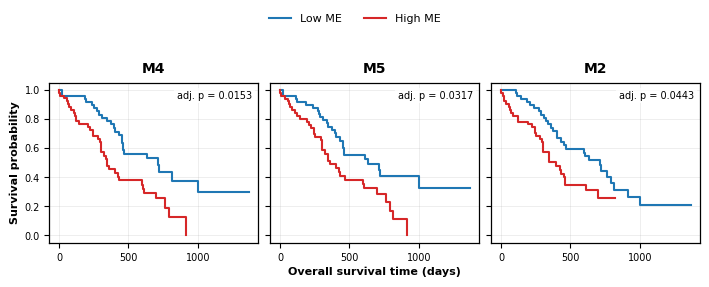

In [6]:
import matplotlib.pyplot as plt

RNA_KM_PANEL_FDR_THRESHOLD = 0.05

rna_km_panel_outputs = survival_utils.build_significant_module_km_panel(
    survival_matrix_rna,
    km_results_rna,
    dataset="RNA",
    output_dir=ctx.output_dir,
    fdr_threshold=RNA_KM_PANEL_FDR_THRESHOLD,
    save_figures=ctx.save_figures,
 )

display(rna_km_panel_outputs["results"][["module", "km_p_value", "km_p_value_fdr", "direction"]])
print(f"Saved three-panel RNA KM figure to {rna_km_panel_outputs['png_path']}")
print(f"Saved RNA KM panel data to {rna_km_panel_outputs['data_path']}")
display(rna_km_panel_outputs["figure"])
plt.close(rna_km_panel_outputs["figure"])

## Step 3: Gene-Level Survival Panels

The subsequent gene-level analyses report Kaplan-Meier/log-rank results with FDR-adjusted p-values.

In [5]:
GCC_HUB_DEGREE_THRESHOLD = 50
GCC_HUB_GENE_PANEL, RNA_GCC_HUBS, PROTEIN_GCC_HUBS = build_top_hub_gene_panel(
    ctx,
    degree_threshold=GCC_HUB_DEGREE_THRESHOLD,
 )
RNA_GCC_HUB_GENES = RNA_GCC_HUBS["gene"].astype(str).tolist()
PROTEIN_GCC_HUB_GENES = PROTEIN_GCC_HUBS["gene"].astype(str).tolist()

USER_DEFINED_GENES = ["SEPT2"]

print(
    f"Testing all {len(RNA_GCC_HUB_GENES)} RNA GCC hubs with >= {GCC_HUB_DEGREE_THRESHOLD} edges in RNA and "
    f"all {len(PROTEIN_GCC_HUB_GENES)} protein GCC hubs with >= {GCC_HUB_DEGREE_THRESHOLD} edges in protein."
 )
print(f"Testing {len(USER_DEFINED_GENES)} user-defined genes in RNA and protein cohorts.")

Testing all 15 RNA GCC hubs with >= 50 edges in RNA and all 23 protein GCC hubs with >= 50 edges in protein.
Testing 1 user-defined genes in RNA and protein cohorts.


## Step 5: All Hub and User-Defined Gene Survival

Test every GCC hub gene identified with at least 50 edges in its corresponding network: RNA hubs in the RNA cohort and protein hubs in the protein cohort. Then test the user-defined gene list separately. For user-defined genes, only genes found in both the RNA and protein cohorts will be carried forward to the survival analysis.

In [7]:
gcc_hub_gene_outputs = survival_utils.run_dataset_specific_gene_panel_pair(
    ctx,
    RNA_GCC_HUB_GENES,
    PROTEIN_GCC_HUB_GENES,
    output_stem="gcc_hub",
    rna_panel_label=f"All RNA GCC hubs with >= {GCC_HUB_DEGREE_THRESHOLD} edges",
    protein_panel_label=f"All protein GCC hubs with >= {GCC_HUB_DEGREE_THRESHOLD} edges",
    rna_candidate_group="rna_gcc_hub",
    protein_candidate_group="protein_gcc_hub",
    tier="tier_3_gcc_hub_gene",
 )

gcc_hub_rna_significant = int((gcc_hub_gene_outputs["rna_results"]["km_p_value_fdr"].fillna(1.0) < 0.1).sum())
gcc_hub_protein_significant = int((gcc_hub_gene_outputs["protein_results"]["km_p_value_fdr"].fillna(1.0) < 0.1).sum())
print(f"Saved GCC hub gene survival results to {ctx.output_dir}")
print(f"Requested hub genes: {len(gcc_hub_gene_outputs['requested_gene_panel'])}")
print(f"RNA-tested hub genes: {len(gcc_hub_gene_outputs['rna_results'])}; significant at FDR < 0.1: {gcc_hub_rna_significant}")
print(f"Protein-tested hub genes: {len(gcc_hub_gene_outputs['protein_results'])}; significant at FDR < 0.1: {gcc_hub_protein_significant}")
if not gcc_hub_gene_outputs["missing_genes"].empty:
    print(f"Missing hub genes not found in expression matrices: {len(gcc_hub_gene_outputs['missing_genes'])}")
print(
    f"Saved {len(gcc_hub_gene_outputs['rna_plot_paths'])} RNA GCC hub gene KM plots with km_p_value_fdr < 0.1 to "
    f"{ctx.output_dir / 'kaplan_meier_rna_gcc_hub_genes'}"
 )
print(
    f"Saved {len(gcc_hub_gene_outputs['protein_plot_paths'])} protein GCC hub gene KM plots with km_p_value_fdr < 0.1 to "
    f"{ctx.output_dir / 'kaplan_meier_protein_gcc_hub_genes'}"
 )

user_defined_gene_outputs = survival_utils.run_shared_gene_panel_survival(
    ctx,
    USER_DEFINED_GENES,
    output_stem="user_defined",
    panel_label="User defined",
    candidate_group="user_defined",
    tier="tier_4_user_gene",
    save_plots=False,
 )

user_defined_rna_significant = int((user_defined_gene_outputs["rna_results"]["km_p_value_fdr"].fillna(1.0) < 0.1).sum())
user_defined_protein_significant = int((user_defined_gene_outputs["protein_results"]["km_p_value_fdr"].fillna(1.0) < 0.1).sum())
print(f"Saved user-defined gene survival results to {ctx.output_dir}")
print(f"Requested user-defined genes: {len(user_defined_gene_outputs['requested_gene_panel'])}")
print(
    f"Shared user-defined genes available in both cohorts: {len(user_defined_gene_outputs['shared_gene_panel'])}"
 )
print(f"RNA-tested user-defined genes: {len(user_defined_gene_outputs['rna_results'])}; significant at FDR < 0.1: {user_defined_rna_significant}")
print(f"Protein-tested user-defined genes: {len(user_defined_gene_outputs['protein_results'])}; significant at FDR < 0.1: {user_defined_protein_significant}")
if not user_defined_gene_outputs["missing_genes"].empty:
    print(f"Missing user-defined genes: {len(user_defined_gene_outputs['missing_genes'])}")
print("User-defined Kaplan-Meier plots are disabled in this notebook.")

Saved GCC hub gene survival results to C:\Users\tiril\Master-Tiril\results\notebooks\01_survival_analysis
Requested hub genes: 38
RNA-tested hub genes: 15; significant at FDR < 0.1: 4
Protein-tested hub genes: 23; significant at FDR < 0.1: 1
Saved 4 RNA GCC hub gene KM plots with km_p_value_fdr < 0.1 to C:\Users\tiril\Master-Tiril\results\notebooks\01_survival_analysis\kaplan_meier_rna_gcc_hub_genes
Saved 1 protein GCC hub gene KM plots with km_p_value_fdr < 0.1 to C:\Users\tiril\Master-Tiril\results\notebooks\01_survival_analysis\kaplan_meier_protein_gcc_hub_genes
Saved user-defined gene survival results to C:\Users\tiril\Master-Tiril\results\notebooks\01_survival_analysis
Requested user-defined genes: 1
Shared user-defined genes available in both cohorts: 1
RNA-tested user-defined genes: 1; significant at FDR < 0.1: 0
Protein-tested user-defined genes: 1; significant at FDR < 0.1: 0
User-defined Kaplan-Meier plots are disabled in this notebook.


## Step 6: Congruent D Node Survival

Test survival only for shared GCC nodes that are classified as congruent D in both RNA and protein.

In [18]:
congruent_d_gene_outputs = survival_utils.run_overlap_file_gene_panel_survival(
    ctx,
    notebook_name="02a_overlap",
    file_name="GCC_overlap_concordant_d_nodes.csv",
    output_stem="congruent_d",
    panel_label="Congruent D shared GCC nodes",
    candidate_group="congruent_d_node",
    tier="tier_3_congruent_d_gene",
    agreement_label="Congruent D",
 )

congruent_d_rna_significant = int((congruent_d_gene_outputs["rna_results"]["km_p_value_fdr"].fillna(1.0) < 0.1).sum())
congruent_d_protein_significant = int((congruent_d_gene_outputs["protein_results"]["km_p_value_fdr"].fillna(1.0) < 0.1).sum())
print(f"Testing {len(congruent_d_gene_outputs['genes'])} congruent D genes.")
print(
    f"{len(congruent_d_gene_outputs['shared_gene_panel'])} genes were available in both RNA and protein survival inputs."
 )
print(f"RNA-tested congruent D genes: {len(congruent_d_gene_outputs['rna_results'])}; significant at FDR < 0.1: {congruent_d_rna_significant}")
print(f"Protein-tested congruent D genes: {len(congruent_d_gene_outputs['protein_results'])}; significant at FDR < 0.1: {congruent_d_protein_significant}")
if not congruent_d_gene_outputs["missing_genes"].empty:
    print(f"Missing congruent D genes: {len(congruent_d_gene_outputs['missing_genes'])}")
print(f"Saved congruent D survival results to {ctx.output_dir}")
print(
    f"Saved {len(congruent_d_gene_outputs['rna_plot_paths'])} RNA congruent D gene KM plots with km_p_value_fdr < 0.1 to "
    f"{ctx.output_dir / 'kaplan_meier_rna_congruent_d_genes'}"
 )
print(
    f"Saved {len(congruent_d_gene_outputs['protein_plot_paths'])} protein congruent D gene KM plots with km_p_value_fdr < 0.1 to "
    f"{ctx.output_dir / 'kaplan_meier_protein_congruent_d_genes'}"
 )

Testing 35 congruent D genes.
35 genes were available in both RNA and protein survival inputs.
RNA-tested congruent D genes: 35; significant at FDR < 0.1: 13
Protein-tested congruent D genes: 35; significant at FDR < 0.1: 2
Saved congruent D survival results to C:\Users\tiril\Master-Tiril\results\notebooks\01_survival_analysis
Saved 13 RNA congruent D gene KM plots with km_p_value_fdr < 0.1 to C:\Users\tiril\Master-Tiril\results\notebooks\01_survival_analysis\kaplan_meier_rna_congruent_d_genes
Saved 2 protein congruent D gene KM plots with km_p_value_fdr < 0.1 to C:\Users\tiril\Master-Tiril\results\notebooks\01_survival_analysis\kaplan_meier_protein_congruent_d_genes


## Step 7: Discordant Node Survival

Test survival only for shared GCC nodes with discordant dominant C/S/D classification between RNA and protein.

In [19]:
discordant_gene_outputs = survival_utils.run_overlap_file_gene_panel_survival(
    ctx,
    notebook_name="02a_overlap",
    file_name="GCC_overlap_discordant_nodes.csv",
    output_stem="discordant",
    panel_label="Discordant shared GCC nodes",
    candidate_group="discordant_node",
    tier="tier_3_discordant_gene",
    agreement_label="DISCORDANT",
 )

discordant_rna_significant = int((discordant_gene_outputs["rna_results"]["km_p_value_fdr"].fillna(1.0) < 0.1).sum())
discordant_protein_significant = int((discordant_gene_outputs["protein_results"]["km_p_value_fdr"].fillna(1.0) < 0.1).sum())
print(f"Testing {len(discordant_gene_outputs['genes'])} discordant genes.")
print(
    f"{len(discordant_gene_outputs['shared_gene_panel'])} genes were available in both RNA and protein survival inputs."
 )
print(f"RNA-tested discordant genes: {len(discordant_gene_outputs['rna_results'])}; significant at FDR < 0.1: {discordant_rna_significant}")
print(f"Protein-tested discordant genes: {len(discordant_gene_outputs['protein_results'])}; significant at FDR < 0.1: {discordant_protein_significant}")
if not discordant_gene_outputs["missing_genes"].empty:
    print(f"Missing discordant genes: {len(discordant_gene_outputs['missing_genes'])}")
print(f"Saved discordant survival results to {ctx.output_dir}")
print(
    f"Saved {len(discordant_gene_outputs['rna_plot_paths'])} RNA discordant gene KM plots with km_p_value_fdr < 0.1 to "
    f"{ctx.output_dir / 'kaplan_meier_rna_discordant_genes'}"
 )
print(
    f"Saved {len(discordant_gene_outputs['protein_plot_paths'])} protein discordant gene KM plots with km_p_value_fdr < 0.1 to "
    f"{ctx.output_dir / 'kaplan_meier_protein_discordant_genes'}"
 )

Testing 109 discordant genes.
109 genes were available in both RNA and protein survival inputs.
RNA-tested discordant genes: 109; significant at FDR < 0.1: 16
Protein-tested discordant genes: 109; significant at FDR < 0.1: 1
Saved discordant survival results to C:\Users\tiril\Master-Tiril\results\notebooks\01_survival_analysis
Saved 16 RNA discordant gene KM plots with km_p_value_fdr < 0.1 to C:\Users\tiril\Master-Tiril\results\notebooks\01_survival_analysis\kaplan_meier_rna_discordant_genes
Saved 1 protein discordant gene KM plots with km_p_value_fdr < 0.1 to C:\Users\tiril\Master-Tiril\results\notebooks\01_survival_analysis\kaplan_meier_protein_discordant_genes


## Step 8: Congruent S and C Node Survival

Test survival for shared GCC nodes classified as congruent S or congruent C in both RNA and protein.

In [20]:
congruent_s_survival = survival_utils.run_overlap_file_gene_panel_survival(
    ctx,
    notebook_name="02a_overlap",
    file_name="GCC_overlap_concordant_s_nodes.csv",
    output_stem="congruent_s",
    panel_label="Congruent S shared GCC nodes",
    candidate_group="congruent_s_node",
    tier="tier_3_congruent_s_gene",
    agreement_label="Congruent S",
 )
congruent_c_survival = survival_utils.run_overlap_file_gene_panel_survival(
    ctx,
    notebook_name="02a_overlap",
    file_name="GCC_overlap_concordant_c_nodes.csv",
    output_stem="congruent_c",
    panel_label="Congruent C shared GCC nodes",
    candidate_group="congruent_c_node",
    tier="tier_3_congruent_c_gene",
    agreement_label="Congruent C",
 )

for survival_output in [congruent_s_survival, congruent_c_survival]:
    agreement_label = survival_output["agreement_label"]
    rna_significant = int((survival_output["rna_results"]["km_p_value_fdr"].fillna(1.0) < 0.1).sum())
    protein_significant = int((survival_output["protein_results"]["km_p_value_fdr"].fillna(1.0) < 0.1).sum())
    print(f"Testing {len(survival_output['genes'])} {agreement_label} genes.")
    print(
        f"{len(survival_output['shared_gene_panel'])} genes were available in both RNA and protein survival inputs."
    )
    print(f"RNA-tested {agreement_label} genes: {len(survival_output['rna_results'])}; significant at FDR < 0.1: {rna_significant}")
    print(f"Protein-tested {agreement_label} genes: {len(survival_output['protein_results'])}; significant at FDR < 0.1: {protein_significant}")
    if not survival_output["missing_genes"].empty:
        print(f"Missing {agreement_label} genes: {len(survival_output['missing_genes'])}")
    print(f"Saved {agreement_label} survival results to {ctx.output_dir}")
    print(f"Saved {len(survival_output['rna_plot_paths'])} RNA {agreement_label} gene KM plots with km_p_value_fdr < 0.1.")
    print(f"Saved {len(survival_output['protein_plot_paths'])} protein {agreement_label} gene KM plots with km_p_value_fdr < 0.1.")

Testing 21 Congruent S genes.
21 genes were available in both RNA and protein survival inputs.
RNA-tested Congruent S genes: 21; significant at FDR < 0.1: 1
Protein-tested Congruent S genes: 21; significant at FDR < 0.1: 0
Saved Congruent S survival results to C:\Users\tiril\Master-Tiril\results\notebooks\01_survival_analysis
Saved 1 RNA Congruent S gene KM plots with km_p_value_fdr < 0.1.
Saved 0 protein Congruent S gene KM plots with km_p_value_fdr < 0.1.
Testing 32 Congruent C genes.
32 genes were available in both RNA and protein survival inputs.
RNA-tested Congruent C genes: 32; significant at FDR < 0.1: 5
Protein-tested Congruent C genes: 32; significant at FDR < 0.1: 0
Saved Congruent C survival results to C:\Users\tiril\Master-Tiril\results\notebooks\01_survival_analysis
Saved 5 RNA Congruent C gene KM plots with km_p_value_fdr < 0.1.
Saved 0 protein Congruent C gene KM plots with km_p_value_fdr < 0.1.
